# Lesson 2 — Homework

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/djnzx/ida-practice-3d/blob/main/practice/2/2-homework.ipynb)

**Estimated time: 3-4 hours.**

## How to work through this

Each task gives a function signature and a docstring stating exactly what
the function must return. Replace `raise NotImplementedError` with your
implementation; the cell after it asserts the behaviour.

**A failing assert is information, not a grade.** Read it, fix the
function, re-run.

The written questions are marked and they carry the real learning
objective. Each asks you to **run something both ways and explain the
difference**, using numbers you produced. One sentence will not be enough.

Every function you need is demonstrated in `2-practice.ipynb`, and each task
names the section. You should not need any other documentation.

## Before you submit

**Runtime → Restart and run all must complete without error** with every
assert passing. Then **File → Download → Download .ipynb**, rename the file to
`2-homework-results.ipynb`, and commit it to your fork under
`practice/2/`. Keep the outputs in the file; do not clear them.
The full procedure is in `practice/README.md` §8.

## 1. Setup

In [12]:
import sys

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 20250919
rng = np.random.default_rng(SEED)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (7.0, 4.5)
plt.rcParams["figure.dpi"] = 110

print("python", sys.version.split()[0], "| pandas", pd.__version__, "| seaborn", sns.__version__)

python 3.13.15 | pandas 2.2.3 | seaborn 0.13.2


In [13]:
titanic = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/titanic.csv"
)
wine = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/wine.csv"
)
bikes = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/bike_sharing_hourly.csv"
)

print("titanic", titanic.shape, "| wine", wine.shape, "| bikes", bikes.shape)

titanic (891, 12) | wine (178, 14) | bikes (17379, 17)


In [14]:
# LOCAL ALTERNATIVE. Run EITHER this cell OR the one above, not both.
# Above reads over the network and is what Colab needs. This one reads
# the same files from your checkout, for the dev-env container. The
# data is identical; only the address differs.
titanic = pd.read_csv("../datasets/titanic.csv")
wine = pd.read_csv("../datasets/wine.csv")
bikes = pd.read_csv("../datasets/bike_sharing_hourly.csv")

print("titanic", titanic.shape, "| wine", wine.shape, "| bikes", bikes.shape)

FileNotFoundError: [Errno 2] No such file or directory: '../datasets/titanic.csv'

## 2. Task 1 — A missingness report

Mechanical.

*see Practice 2 §5.1*

In [15]:
def missing_report(frame):
    missing = frame.isna().sum()

    missing = missing[missing > 0]

    report = pd.DataFrame({
        "missing": missing,
        "percent": (missing / len(frame) * 100).round(2)
    })

    return report.sort_values("missing", ascending=False)

In [16]:
_report = missing_report(titanic)

assert list(_report.columns) == ["missing", "percent"], f"columns wrong: {list(_report.columns)}"
assert len(_report) == 3, f"Titanic has three columns with gaps, you reported {len(_report)}"
assert list(_report.index) == ["Cabin", "Age", "Embarked"], \
    f"wrong columns or wrong order: {list(_report.index)}"
assert _report.loc["Cabin", "missing"] == 687
assert _report.loc["Age", "missing"] == 177
assert _report.loc["Embarked", "missing"] == 2
assert np.isclose(_report.loc["Age", "percent"], 19.87, atol=0.01), \
    f"percent should be 100 * 177/891 = 19.87, got {_report.loc['Age', 'percent']}"

# a frame with no gaps produces an empty report, not an error
assert len(missing_report(wine)) == 0, "wine.csv has no missing values"

print(_report)
print("\nTask 1 passed.")

          missing  percent
Cabin         687  77.1000
Age           177  19.8700
Embarked        2   0.2200

Task 1 passed.


## 3. Task 2 — Label against position

Mechanical, and the trap is real. After a sort, `.loc` and `.iloc` answer
different questions.

*see Practice 2 §4*

In [17]:
def first_and_labelled(frame, sort_column, label):
    sorted_frame = frame.sort_values(sort_column, ascending=False)

    top_row = sorted_frame.iloc[0]
    labelled_row = sorted_frame.loc[label]

    return top_row, labelled_row

In [18]:
_top, _labelled = first_and_labelled(titanic, "Fare", 0)

assert isinstance(_top, pd.Series) and isinstance(_labelled, pd.Series)
assert np.isclose(_top["Fare"], 512.3292), \
    f"the highest fare is 512.3292, you returned {_top['Fare']}"
assert _labelled["Name"] == "Braund, Mr. Owen Harris", \
    f"label 0 is Braund, you returned {_labelled['Name']}"
assert np.isclose(_labelled["Fare"], 7.25)
assert _top["Name"] != _labelled["Name"], \
    "position 0 and label 0 must be different passengers after sorting"

print("position 0 after sorting:", _top["Name"], "| fare", round(_top["Fare"], 2))
print("label 0 after sorting   :", _labelled["Name"], "| fare", round(_labelled["Fare"], 2))
print("\nTask 2 passed.")

position 0 after sorting: Cardeza, Mr. Thomas Drake Martinez | fare 512.33
label 0 after sorting   : Braund, Mr. Owen Harris | fare 7.25

Task 2 passed.


## 4. Task 3 — Group-wise imputation, without the chained-assignment bug

Applied. Fill missing ages with the median of the passenger's
`(Pclass, Sex)` group, and do it without triggering a
`SettingWithCopyWarning`.

*see Practice 2 §4.2, §5.4 and §6.3*

In [19]:
def fill_age_by_group(frame):
    result = frame.copy()

    group_medians = result.groupby(["Pclass", "Sex"])["Age"].transform("median")

    result["Age"] = result["Age"].fillna(group_medians)

    return result

In [20]:
import warnings

_before_missing = int(titanic["Age"].isna().sum())

with warnings.catch_warnings():
    warnings.simplefilter("error")          # any pandas warning becomes an exception
    _filled = fill_age_by_group(titanic)

assert int(titanic["Age"].isna().sum()) == _before_missing, "the argument was modified"
assert int(_filled["Age"].isna().sum()) == 0, "some ages are still missing"
assert len(_filled) == len(titanic), "rows were added or lost"

# The ages that were already present must be untouched.
_present = titanic["Age"].notna()
assert np.allclose(_filled.loc[_present, "Age"], titanic.loc[_present, "Age"]), \
    "existing ages were altered"

# A filled passenger must receive their own group's median, not the global one.
_a_gap = titanic.index[titanic["Age"].isna()][0]
_pclass, _sex = titanic.loc[_a_gap, "Pclass"], titanic.loc[_a_gap, "Sex"]
_expected = titanic[(titanic["Pclass"] == _pclass) & (titanic["Sex"] == _sex)]["Age"].median()
assert np.isclose(_filled.loc[_a_gap, "Age"], _expected), \
    f"passenger {_a_gap} got {_filled.loc[_a_gap, 'Age']}, expected group median {_expected}"

print(f"filled {_before_missing} ages; std went from "
      f"{titanic['Age'].std():.4f} to {_filled['Age'].std():.4f}")
print("Task 3 passed.")

filled 177 ages; std went from 14.5265 to 13.3044
Task 3 passed.


## 5. Task 4 — Four imputations, four distributions

Applied.

*see Practice 2 §5.4*

In [21]:
def compare_imputations(frame, column="Age"):
    dropna = frame[column].dropna()

    mean_filled = frame[column].fillna(frame[column].mean())

    median_filled = frame[column].fillna(frame[column].median())

    group_medians = frame.groupby(["Pclass", "Sex"])[column].transform("median")
    group_filled = frame[column].fillna(group_medians)

    result = pd.DataFrame({
        "n": [
            dropna.count(),
            mean_filled.count(),
            median_filled.count(),
            group_filled.count()
        ],
        "mean": [
            dropna.mean(),
            mean_filled.mean(),
            median_filled.mean(),
            group_filled.mean()
        ],
        "median": [
            dropna.median(),
            mean_filled.median(),
            median_filled.median(),
            group_filled.median()
        ],
        "std": [
            dropna.std(),
            mean_filled.std(),
            median_filled.std(),
            group_filled.std()
        ]
    }, index=["dropna", "mean", "median", "group_median"])

    return result

In [22]:
_comparison = compare_imputations(titanic)

assert list(_comparison.index) == ["dropna", "mean", "median", "group_median"]
assert list(_comparison.columns) == ["n", "mean", "median", "std"]
assert _comparison.loc["dropna", "n"] == 714, "dropna keeps the 714 recorded ages"
assert _comparison.loc["mean", "n"] == 891, "filling keeps all 891 rows"

# Filling with the mean preserves the mean exactly and shrinks the spread.
assert np.isclose(_comparison.loc["mean", "mean"], titanic["Age"].mean()), \
    "filling with the mean must leave the mean unchanged"
assert _comparison.loc["mean", "std"] < _comparison.loc["dropna", "std"], \
    "stacking 177 rows on one value must reduce the standard deviation"

# The group-wise fill distorts the spread less than a single constant does.
assert _comparison.loc["group_median", "std"] > _comparison.loc["mean", "std"], \
    "the group-wise fill should preserve more of the spread than a constant fill"

print(_comparison.round(4))
print("\nTask 4 passed.")

                n    mean  median     std
dropna        714 29.6991 28.0000 14.5265
mean          891 29.6991 29.6991 13.0020
median        891 29.3616 28.0000 13.0197
group_median  891 29.1124 26.0000 13.3044

Task 4 passed.


### Question 1 — choosing an imputation

Using the table you just produced, and a histogram of each of the four
resulting distributions:

**(a)** Filling with the mean leaves the mean **exactly** unchanged and
still damages the data. What quantity did it damage, by how much, and why
does preserving the mean not make the fill harmless?

**(b)** Compare `dropna` with the three fills. Dropping loses 177 rows,
20 % of the data. Under what condition about *why* the values are missing
is dropping unbiased, and is that condition plausible for Titanic's `Age`?
Name the MCAR / MAR / MNAR category you think applies and give your
evidence.

**(c)** You must pick one strategy and defend it to a reviewer. Pick one
and write the defence in three sentences.

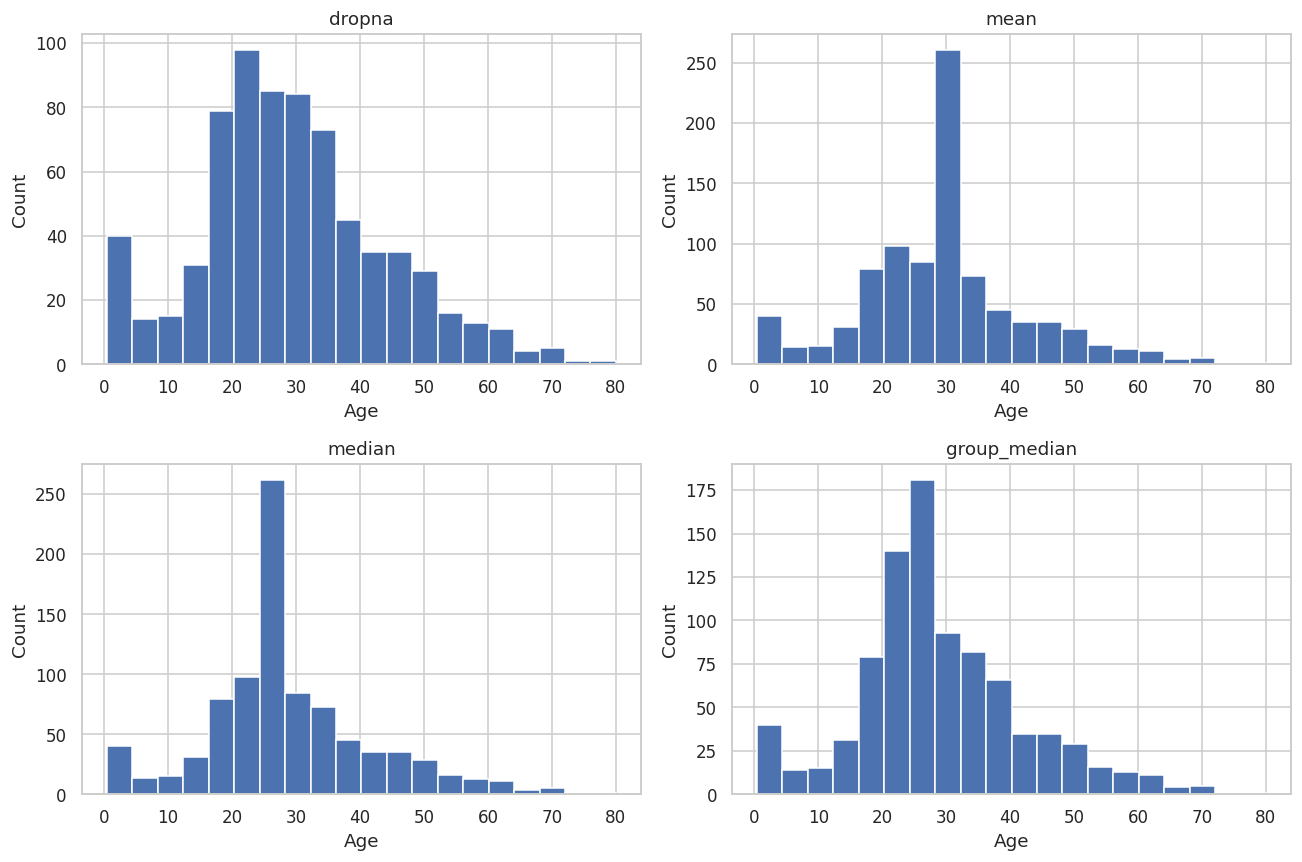

In [23]:
age = titanic["Age"]

distributions = {
    "dropna": age.dropna(),
    "mean": age.fillna(age.mean()),
    "median": age.fillna(age.median()),
    "group_median": age.fillna(
        titanic.groupby(["Pclass", "Sex"])["Age"].transform("median")
    )
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, (name, values) in zip(axes.ravel(), distributions.items()):
    ax.hist(values, bins=20)
    ax.set_title(name)
    ax.set_xlabel("Age")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

**Your answer:**

**(a)** Filling the missing ages with the mean leaves the mean unchanged at 29.6991, but it reduces the standard deviation from 14.5265 to 13.0020, a decrease of 1.5245 years (about 10.5%). This happens because all 177 missing values are replaced by the same value, 29.6991, so they add no variation around the mean. Therefore, preserving the mean does not make mean imputation harmless because it changes the spread and shape of the distribution.

**(b)** Dropping the missing values is unbiased only if the missingness is MCAR, meaning that the probability of `Age` being missing is unrelated to both observed and unobserved characteristics. For Titanic's `Age`, MCAR is not very plausible because whether age was recorded may be related to other passenger characteristics, while the dataset contains variables such as `Pclass` and `Sex` that can be used to explain differences between groups. Therefore, MAR is a more plausible assumption than MCAR, although the dataset alone cannot prove the exact missingness mechanism.

**(c)** I would choose the `group_median` strategy because it fills missing values using the passenger's `Pclass` and `Sex` rather than one global value. Its standard deviation is 13.3044, compared with 13.0020 for mean imputation, so it preserves more of the observed variation. Although it still changes the distribution, it makes use of relevant observed group information and is therefore more defensible for this dataset.


## 6. Task 5 — The IQR rule

Applied. Implement the rule behind a boxplot's whiskers.

*see Practice 2 §10.4*

In [24]:
def iqr_outliers(series, multiplier=1.5):
    q1 = float(series.quantile(0.25))
    q3 = float(series.quantile(0.75))

    iqr = q3 - q1

    lower = q1 - multiplier * iqr
    upper = q3 + multiplier * iqr

    mask = (series < lower) | (series > upper)
    mask = mask.fillna(False)

    return {
        "q1": q1,
        "q3": q3,
        "lower": float(lower),
        "upper": float(upper),
        "mask": mask
    }

In [25]:
_fare = iqr_outliers(titanic["Fare"], multiplier=1.5)

assert set(_fare) == {"q1", "q3", "lower", "upper", "mask"}
assert np.isclose(_fare["q1"], 7.9104, atol=1e-3), f"Q1 wrong: {_fare['q1']}"
assert np.isclose(_fare["q3"], 31.0, atol=1e-6), f"Q3 wrong: {_fare['q3']}"
assert np.isclose(_fare["upper"], 65.6344, atol=1e-3), f"upper fence wrong: {_fare['upper']}"
assert _fare["mask"].dtype == bool
assert int(_fare["mask"].sum()) == 116, \
    f"the 1.5 x IQR rule flags 116 fares, you found {int(_fare['mask'].sum())}"

# A larger multiplier can never flag more points.
assert iqr_outliers(titanic["Fare"], 3.0)["mask"].sum() <= _fare["mask"].sum()

# Missing values must not be flagged.
_age_flags = iqr_outliers(titanic["Age"])["mask"]
assert not _age_flags[titanic["Age"].isna()].any(), "a missing value is not an outlier"
assert len(_age_flags) == len(titanic), "the mask must align to the input"

print(f"Fare: Q1 {_fare['q1']:.2f}, Q3 {_fare['q3']:.2f}, "
      f"fences [{_fare['lower']:.2f}, {_fare['upper']:.2f}], {int(_fare['mask'].sum())} flagged")
print("Task 5 passed.")

Fare: Q1 7.91, Q3 31.00, fences [-26.72, 65.63], 116 flagged
Task 5 passed.


### Question 2 — the multiplier, and two rules that disagree

**(a)** Run `iqr_outliers` on `Fare` at multipliers 1.0, 1.5, 3.0 and 5.0
and report the count at each. Then compute the 3σ count from Practice 1
§4.7 on the same column. Tabulate all five numbers.

**(b)** The IQR rule and the 3σ rule disagree sharply on `Fare`. Explain
*why*, referring to the shape of the distribution. Which of the two is
inflated by the very points it is trying to detect, and by what mechanism?

**(c)** Now run both rules on `Age` instead. Do they still disagree as
much? What is different about `Age` that changes the answer?

**(d)** For `Fare`, would you remove any of the flagged points? Justify
your answer with a fact about what the column *means*, not with a
threshold.

In [26]:
def sigma_outliers(series, k=3):
    mean = series.mean()
    std = series.std()
    return ((series < mean - k * std) | (series > mean + k * std)).fillna(False)


multipliers = [1.0, 1.5, 3.0, 5.0]

fare_counts = {
    f"IQR {m}": int(iqr_outliers(titanic["Fare"], m)["mask"].sum())
    for m in multipliers
}

fare_counts["3-sigma"] = int(sigma_outliers(titanic["Fare"], 3).sum())

age_counts = {
    f"IQR {m}": int(iqr_outliers(titanic["Age"], m)["mask"].sum())
    for m in multipliers
}

age_counts["3-sigma"] = int(sigma_outliers(titanic["Age"], 3).sum())

print("Fare:")
for rule, count in fare_counts.items():
    print(f"{rule:10s}: {count}")

print("\nAge:")
for rule, count in age_counts.items():
    print(f"{rule:10s}: {count}")

print("\n3-sigma Fare limits:")
fare_mean = titanic["Fare"].mean()
fare_std = titanic["Fare"].std()
print(f"mean = {fare_mean:.4f}, std = {fare_std:.4f}")
print(f"lower = {fare_mean - 3 * fare_std:.4f}")
print(f"upper = {fare_mean + 3 * fare_std:.4f}")

print("\n3-sigma Age limits:")
age_mean = titanic["Age"].mean()
age_std = titanic["Age"].std()
print(f"mean = {age_mean:.4f}, std = {age_std:.4f}")
print(f"lower = {age_mean - 3 * age_std:.4f}")
print(f"upper = {age_mean + 3 * age_std:.4f}")

Fare:
IQR 1.0   : 141
IQR 1.5   : 116
IQR 3.0   : 53
IQR 5.0   : 31
3-sigma   : 20

Age:
IQR 1.0   : 63
IQR 1.5   : 11
IQR 3.0   : 0
IQR 5.0   : 0
3-sigma   : 2

3-sigma Fare limits:
mean = 32.2042, std = 49.6934
lower = -116.8761
upper = 181.2845

3-sigma Age limits:
mean = 29.6991, std = 14.5265
lower = -13.8804
upper = 73.2786


**Your answer:**

**(a)** The number of `Fare` outliers decreases as the IQR multiplier increases: 141 at 1.0, 116 at 1.5, 53 at 3.0, and 31 at 5.0. The 3σ rule flags only 20 `Fare` values. For `Age`, the corresponding IQR counts are 63, 11, 0, and 0, while the 3σ rule flags 2 values.

| Rule    | Fare | Age |
| ------- | ---: | --: |
| IQR 1.0 |  141 |  63 |
| IQR 1.5 |  116 |  11 |
| IQR 3.0 |   53 |   0 |
| IQR 5.0 |   31 |   0 |
| 3σ      |   20 |   2 |

**(b)** The `Fare` distribution is strongly right-skewed: most fares are relatively small, while a small number of fares are very large. The mean and standard deviation are sensitive to these large values; in this dataset the mean is 32.2042 and the standard deviation is 49.6934, producing a very high 3σ upper fence of 181.2845. Therefore, the 3σ rule is inflated by the extreme fares themselves: they increase the standard deviation, which moves the upper fence upward and causes some extreme values to no longer be flagged. The IQR rule is less affected because quartiles are more resistant to a small number of extreme observations.

**(c)** The two rules disagree much less for `Age`: the 1.5×IQR rule flags 11 observations, while the 3σ rule flags 2. `Age` has a much less extreme right tail than `Fare`, so its mean and standard deviation are not inflated as strongly by a small number of very large observations. In this case the 3σ upper fence is 73.2786, while the IQR rule has a much tighter upper fence, so the remaining difference is mainly due to the different definitions of an outlier rather than a severe skewness problem.

**(d)** I would not automatically remove the flagged `Fare` values. `Fare` represents the amount paid for a ticket, so a very large value can be a legitimate observation rather than a data-entry error. An outlier rule identifies unusual values statistically, but it does not establish that the corresponding ticket price is incorrect.


## 7. Task 6 — Pearson against Spearman

Applied. Two coefficients, two different questions about the same pair of
columns.

*see Practice 2 §11.2*

In [27]:
def correlation_pair(frame, column_a, column_b):
    """Compare the two correlation coefficients for one pair of columns.

    Return a dict with exactly these three keys:
        'pearson'     the Pearson coefficient, measuring LINEAR association
        'spearman'    the Spearman coefficient, measuring MONOTONIC association
        'difference'  pearson - spearman

    Use pandas' Series.corr(method=...). Return Python floats.
    """
    pearson = frame[column_a].corr(frame[column_b], method="pearson")
    spearman = frame[column_a].corr(frame[column_b], method="spearman")

    difference = pearson - spearman

    return {
        "pearson": float(pearson),
        "spearman": float(spearman),
        "difference": float(difference)
    }

In [28]:
_pair = correlation_pair(wine, "flavanoids", "total_phenols")

assert set(_pair) == {"pearson", "spearman", "difference"}
assert np.isclose(_pair["pearson"], 0.8646, atol=1e-3), f"pearson wrong: {_pair['pearson']}"
assert np.isclose(_pair["spearman"], 0.8794, atol=1e-3), f"spearman wrong: {_pair['spearman']}"
assert np.isclose(_pair["difference"], _pair["pearson"] - _pair["spearman"])

# A perfectly linear pair: both coefficients are exactly 1.
_linear = pd.DataFrame({"a": [1.0, 2.0, 3.0, 4.0, 5.0], "b": [3.0, 5.0, 7.0, 9.0, 11.0]})
_lin = correlation_pair(_linear, "a", "b")
assert np.isclose(_lin["pearson"], 1.0) and np.isclose(_lin["spearman"], 1.0)

# Monotonic but strongly curved: Spearman sees it fully, Pearson does not.
_curve_rng = np.random.default_rng(SEED)
_x = np.linspace(0.1, 5.0, 300)
_curved = pd.DataFrame({"x": _x, "y": np.exp(_x) + _curve_rng.normal(0, 3, 300)})
_c = correlation_pair(_curved, "x", "y")
assert _c["spearman"] > 0.95, f"a monotonic pair should have Spearman near 1, got {_c['spearman']:.4f}"
assert _c["pearson"] < _c["spearman"] - 0.05, \
    "on a curved monotonic pair Pearson must fall clearly below Spearman"

print(f"wine flavanoids vs total_phenols: pearson {_pair['pearson']:+.4f}  "
      f"spearman {_pair['spearman']:+.4f}")
print(f"curved monotonic pair          : pearson {_c['pearson']:+.4f}  "
      f"spearman {_c['spearman']:+.4f}")
print("Task 6 passed.")

wine flavanoids vs total_phenols: pearson +0.8646  spearman +0.8794
curved monotonic pair          : pearson +0.8605  spearman +0.9653
Task 6 passed.


### Question 3 — two coefficients, and the bandwidth that shapes what you see

**(a)** Scatter-plot the curved pair `_curved` from the cell above. Both
coefficients are high, and they disagree by about 0.10. Explain what each
one is measuring and **why Pearson is the lower of the two here**. Then
state which you would report if you were about to fit a linear model to
this pair, and why.

**(b)** Run `correlation_pair` on `color_intensity` against `hue` in the
wine data. Here the two differ in a different way. Plot the pair and
explain what feature of the data produces the gap.

**(c)** Now a different decision that changes what you see. Take Titanic's
`Age` and draw `sns.kdeplot` at `bw_adjust` = 0.2, 1.0 and 3.0, then draw
a histogram of the same column at 20 and at 200 bins. **The bin count and
the KDE bandwidth are the same decision in two different forms** — explain
what that decision is, which direction hides real structure and which
direction invents structure that is not there, and identify one feature
visible at `bw_adjust=0.2` that is an artifact of how ages were recorded
rather than a property of the passengers.

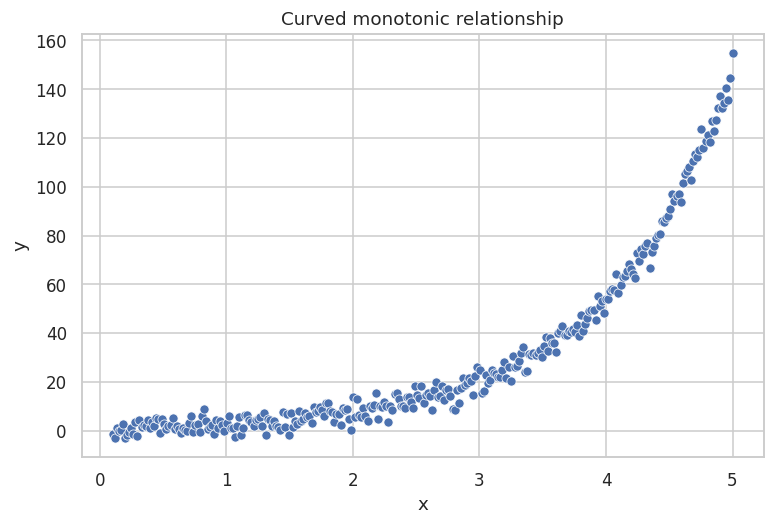

Question 3(a):
Pearson  = 0.8605
Spearman = 0.9653
Difference = -0.1048

Question 3(b):
Pearson  = -0.5218
Spearman = -0.4185
Difference = -0.1033


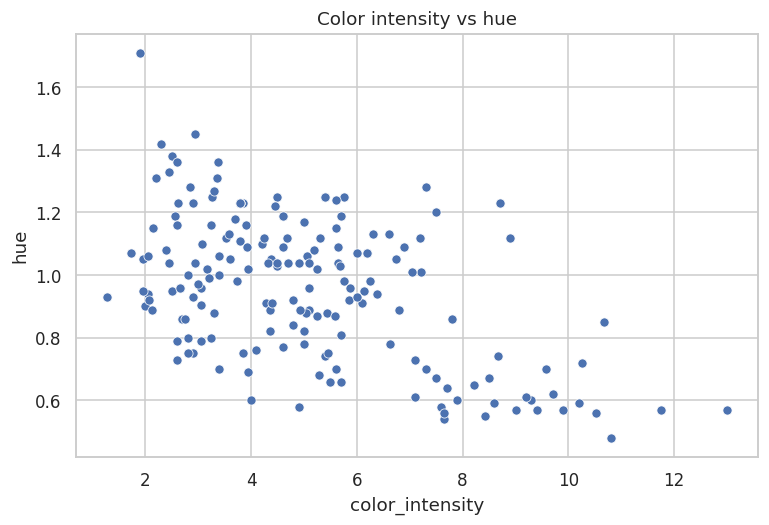

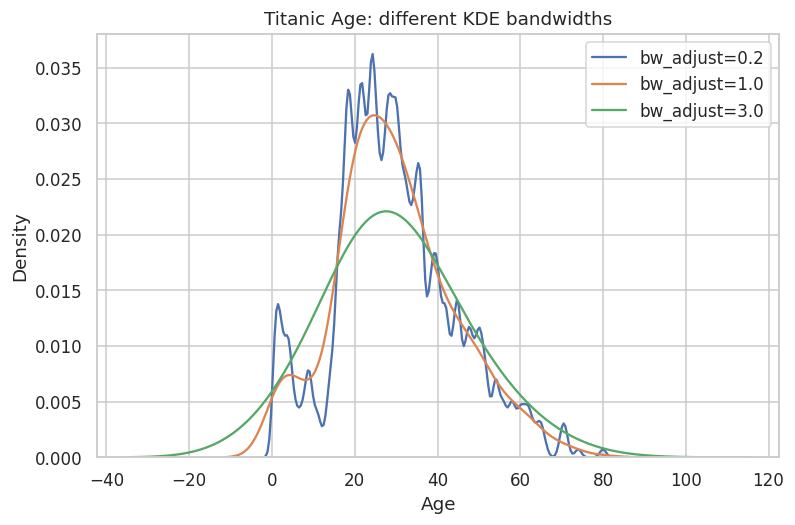

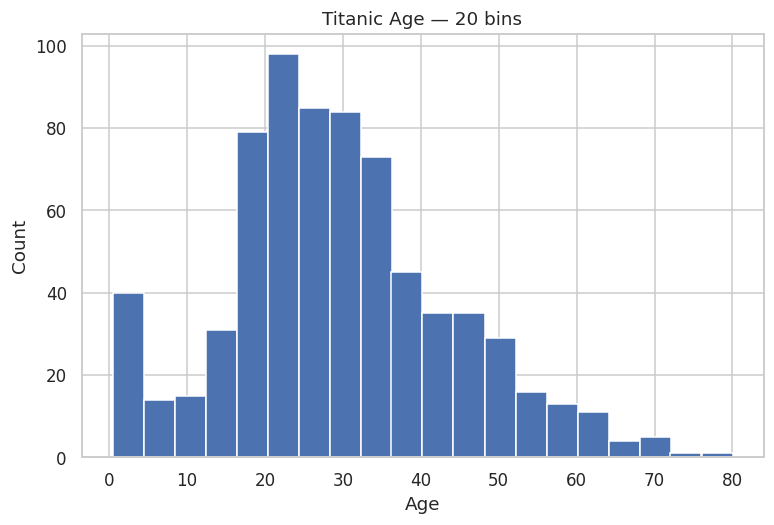

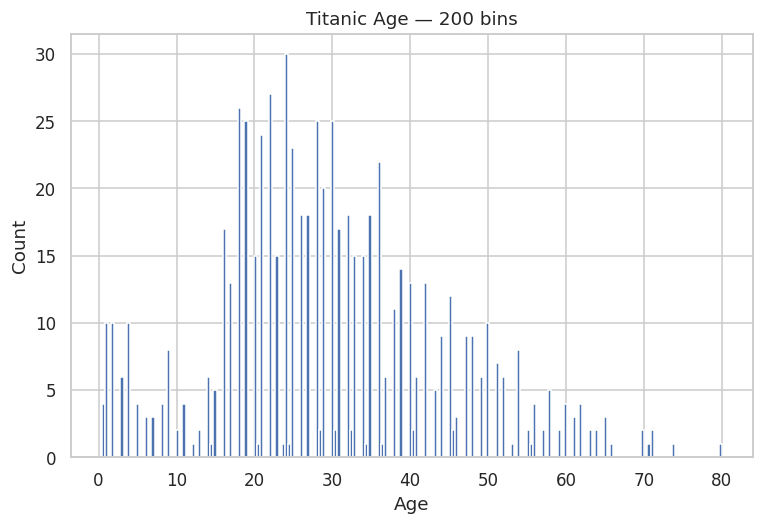

In [29]:
# Question 3(a): scatter plot for the curved pair
plt.figure(figsize=(8, 5))
sns.scatterplot(data=_curved, x="x", y="y")
plt.title("Curved monotonic relationship")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

print("Question 3(a):")
print(f"Pearson  = {_c['pearson']:.4f}")
print(f"Spearman = {_c['spearman']:.4f}")
print(f"Difference = {_c['pearson'] - _c['spearman']:.4f}")


# Question 3(b): color_intensity vs hue
_color_hue = correlation_pair(wine, "color_intensity", "hue")

print("\nQuestion 3(b):")
print(f"Pearson  = {_color_hue['pearson']:.4f}")
print(f"Spearman = {_color_hue['spearman']:.4f}")
print(f"Difference = {_color_hue['difference']:.4f}")

plt.figure(figsize=(8, 5))
sns.scatterplot(data=wine, x="color_intensity", y="hue")
plt.title("Color intensity vs hue")
plt.xlabel("color_intensity")
plt.ylabel("hue")
plt.show()


# Question 3(c): KDE with different bandwidths
plt.figure(figsize=(8, 5))

for bw in [0.2, 1.0, 3.0]:
    sns.kdeplot(data=titanic, x="Age", bw_adjust=bw, label=f"bw_adjust={bw}")

plt.title("Titanic Age: different KDE bandwidths")
plt.xlabel("Age")
plt.ylabel("Density")
plt.legend()
plt.show()


# Histograms with different numbers of bins
plt.figure(figsize=(8, 5))
plt.hist(titanic["Age"].dropna(), bins=20)
plt.title("Titanic Age — 20 bins")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(titanic["Age"].dropna(), bins=200)
plt.title("Titanic Age — 200 bins")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

**Your answer:**

**(a)** The scatter plot shows a strong but curved monotonic relationship between `x` and `y`. Pearson's coefficient is 0.8605, while Spearman's coefficient is 0.9653. Pearson measures the strength of a **linear** relationship, so it is lower because the points follow a curved pattern rather than a straight line. Spearman is based on the ranks of the observations and measures a **monotonic** relationship, so it remains close to 1 even when the relationship is strongly curved. If I were about to fit a linear model to this pair, I would report Pearson because it directly measures the strength of the linear association that the model is intended to represent. However, the scatter plot also shows that a simple linear model may not describe the relationship completely.

**(b)** For `color_intensity` and `hue`, Pearson's coefficient is approximately -0.5218, while Spearman's coefficient is approximately -0.4185. Both coefficients indicate a negative association, but Pearson is more negative than Spearman. The scatter plot shows that the relationship is not well described by a single straight line and that the observations have a nonlinear pattern with different behavior across the range of `color_intensity`. Pearson is more affected by the actual distances between values, while Spearman uses their ranks. Therefore, the difference between the coefficients reflects the nonlinear shape of the relationship rather than simply its direction.

**(c)** The number of histogram bins and the KDE bandwidth are two ways of controlling the amount of smoothing in a visualization. A small number of bins in a histogram or a large KDE bandwidth produces more smoothing and can hide real structure in the data. Conversely, a large number of bins or a very small KDE bandwidth produces a more detailed and less smoothed view, but can make random variation look like meaningful structure.

For the Titanic `Age` variable, `bw_adjust=3.0` gives a very smooth density curve and can hide smaller features of the distribution. At `bw_adjust=0.2`, the KDE follows the individual observations much more closely and produces many narrow peaks. Some of these peaks are artifacts rather than meaningful characteristics of the passengers. In particular, the strong concentration of ages at whole numbers, and especially at ages such as 20, 30, 40 and other round values, reflects that many passenger ages were recorded or reported as rounded values. Therefore, a very small bandwidth can make the recording convention appear as if it were a real multimodal structure in the underlying passenger population.


## 8. Task 7 — Encoding, and the distances it invents

Applied. Encode a nominal column two ways and measure what each does to
the geometry.

*see Practice 2 §13*

In [30]:
def encoding_distances(series):
    """Compare label encoding against one-hot encoding on a nominal column.

    `series` holds categorical text with no missing values.

    Build both encodings:
      - label:   the categories sorted alphabetically, mapped to 0, 1, 2, ...
      - one-hot: one binary column per category

    Then, for every unordered pair of DISTINCT categories, compute the
    Euclidean distance between their encodings under each scheme.

    Return a DataFrame with one row per pair, indexed by the string
    "A|B" with A and B in alphabetical order, and two columns:
        'label_distance'    |code(A) - code(B)|
        'onehot_distance'   the Euclidean distance between the two one-hot rows

    Rows sorted by index.
    """
    categories = sorted(series.unique())

    # Label encoding: alphabetical order -> 0, 1, 2, ...
    label_codes = {
        category: code
        for code, category in enumerate(categories)
    }

    # One-hot encoding: one vector for each category
    onehot_codes = {
        category: [1 if category == current else 0 for current in categories]
        for category in categories
    }

    rows = []

    # Go through every unordered pair of categories
    for i in range(len(categories)):
        for j in range(i + 1, len(categories)):
            a = categories[i]
            b = categories[j]

            label_distance = abs(label_codes[a] - label_codes[b])

            onehot_a = np.array(onehot_codes[a])
            onehot_b = np.array(onehot_codes[b])

            onehot_distance = np.linalg.norm(onehot_a - onehot_b)

            rows.append({
                "pair": f"{a}|{b}",
                "label_distance": float(label_distance),
                "onehot_distance": float(onehot_distance)
            })

    result = pd.DataFrame(rows).set_index("pair")

    return result.sort_index()

In [31]:
_embarked = titanic["Embarked"].fillna("S")
_distances = encoding_distances(_embarked)

assert list(_distances.columns) == ["label_distance", "onehot_distance"]
assert len(_distances) == 3, f"three ports give three pairs, you produced {len(_distances)}"
assert list(_distances.index) == ["C|Q", "C|S", "Q|S"], f"index wrong: {list(_distances.index)}"

# Label encoding invents an ordering: C and S end up twice as far apart.
assert np.isclose(_distances.loc["C|Q", "label_distance"], 1.0)
assert np.isclose(_distances.loc["C|S", "label_distance"], 2.0)
assert np.isclose(_distances.loc["Q|S", "label_distance"], 1.0)

# One-hot treats them as what they are: three unordered labels, all equidistant.
assert np.allclose(_distances["onehot_distance"], np.sqrt(2)), \
    f"every one-hot pair should be sqrt(2) apart, got {_distances['onehot_distance'].tolist()}"
assert _distances["onehot_distance"].nunique() == 1, \
    "one-hot must not distinguish any pair from any other"

print(_distances.round(4))
print("\nTask 7 passed.")

      label_distance  onehot_distance
pair                                 
C|Q           1.0000           1.4142
C|S           2.0000           1.4142
Q|S           1.0000           1.4142

Task 7 passed.


### Question 4 — label against one-hot

**(a)** Under label encoding, C and S are 2 apart while C and Q are 1
apart. Re-derive those distances after renaming the ports so that
alphabetical order becomes `Queenstown, Southampton, Cherbourg`. What
happens to the geometry? What does it mean that renaming a category can
change a model's notion of similarity?

**(b)** `Pclass` also becomes integers 1, 2, 3, and Practice 2 §13.3 says
that is **correct**. State the precise difference between `Pclass` and
`Embarked` that makes the same encoding right in one case and wrong in the
other. Your answer must not mention the data type.

**(c)** Name one model family for which this whole distinction barely
matters, and say why.

In [32]:
# Rename the ports so that alphabetical order becomes:
# Queenstown, Southampton, Cherbourg

renamed_ports = _embarked.replace({
    "C": "Cherbourg",
    "Q": "Queenstown",
    "S": "Southampton"
})

renamed_distances = encoding_distances(renamed_ports)

print(renamed_distances.round(4))

                        label_distance  onehot_distance
pair                                                   
Cherbourg|Queenstown            1.0000           1.4142
Cherbourg|Southampton           2.0000           1.4142
Queenstown|Southampton          1.0000           1.4142


**Your answer:**

(a) After renaming the ports, the label distances become:
Cherbourg–Queenstown = 1, Cherbourg–Southampton = 2, and Queenstown–Southampton = 1. Thus, the geometry changes even though the categories themselves have not changed. This shows that label encoding introduces an arbitrary ordering: renaming categories can change which categories a model considers more similar, even though their actual meaning has not changed.

(b) `Pclass` represents an ordered relationship: 1st class, 2nd class, and 3rd class have a meaningful ranking and the numerical distances reflect that order. `Embarked` represents nominal categories with no natural order, so assigning numbers creates an artificial ranking and distances that have no real meaning.

(c) Tree-based models, such as decision trees and random forests, are less affected by this distinction because they split observations using thresholds rather than relying on Euclidean distance or a linear notion of similarity between category values.

## 9. Task 8 — Scale without leaking

Applied. Split, then fit the scaler on the training half only.

*see Practice 2 §14.3*

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def split_and_scale(X, y, test_size=0.3, random_state=SEED):
    """Split into train and test, then standardise WITHOUT leakage.

    Split first with train_test_split, stratifying on y and using the
    given random_state. Then fit a StandardScaler on the TRAINING features
    only, and use it to transform both halves.

    Return a dict with exactly these five keys:
        'X_train', 'X_test'   the scaled feature arrays
        'y_train', 'y_test'   the labels
        'scaler'              the fitted StandardScaler
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return {
        "X_train": X_train_scaled,
        "X_test": X_test_scaled,
        "y_train": y_train,
        "y_test": y_test,
        "scaler": scaler
    }

In [34]:
_features = [c for c in wine.columns if c != "target"]
_split = split_and_scale(wine[_features].values, wine["target"].values)

assert set(_split) == {"X_train", "X_test", "y_train", "y_test", "scaler"}
assert _split["X_train"].shape[0] + _split["X_test"].shape[0] == len(wine)
assert _split["X_train"].shape[1] == 13

# The TRAINING half must be exactly standardised...
assert np.allclose(_split["X_train"].mean(axis=0), 0.0, atol=1e-10), \
    "the training set should have mean 0 after scaling"
assert np.allclose(_split["X_train"].std(axis=0), 1.0, atol=1e-10), \
    "the training set should have unit variance after scaling"

# ...and the TEST half must NOT be, because its statistics were never used.
assert not np.allclose(_split["X_test"].mean(axis=0), 0.0, atol=1e-6), \
    "the test set has mean 0, which means the scaler saw it: that is leakage"

# The scaler must have been fitted on the training rows only.
_leaky = StandardScaler().fit(wine[_features].values)
assert not np.allclose(_split["scaler"].mean_, _leaky.mean_), \
    "your scaler's means match a scaler fitted on the whole dataset"

# stratify= must preserve the class balance
_train_balance = np.bincount(_split["y_train"]) / len(_split["y_train"])
_full_balance = np.bincount(wine["target"].values) / len(wine)
assert np.allclose(_train_balance, _full_balance, atol=0.02), \
    "the class balance was not preserved; did you pass stratify=y?"

print("train", _split["X_train"].shape, " test", _split["X_test"].shape)
print("train mean (first 3 features):", _split["X_train"].mean(axis=0)[:3].round(10))
print("test  mean (first 3 features):", _split["X_test"].mean(axis=0)[:3].round(4), " <- not zero, correctly")
print("\nTask 8 passed.")

train (124, 13)  test (54, 13)
train mean (first 3 features): [ 0. -0. -0.]
test  mean (first 3 features): [-0.0324  0.0259 -0.0291]  <- not zero, correctly

Task 8 passed.


### Question 5 — scaling choices

**(a)** Repeat Task 8 with `MinMaxScaler` instead. Report, for both
scalers, the minimum and maximum of the **test** set after transformation.
Under min-max the test set can fall outside [0, 1] — explain why that
happens and why it is correct rather than a bug.

**(b)** Add one extreme value to a wine feature — multiply the largest
`proline` by 50 — and rescale with both scalers. Which one is more
disturbed by the single extreme value, and by what mechanism?

**(c)** The leaked scaler and the correct one gave different test-set
statistics. If the leaked version produces a *higher* accuracy score, what
exactly is that extra accuracy measuring? Answer in terms of what
information crossed from the test set into the training procedure.

In [35]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Question 5(a)
X = wine[_features].values
y = wine["target"].values

# StandardScaler
standard_split = split_and_scale(X, y)

# MinMaxScaler: split first, then fit only on training data
X_train_mm, X_test_mm, y_train_mm, y_test_mm = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=SEED,
    stratify=y
)

minmax_scaler = MinMaxScaler()

X_train_mm_scaled = minmax_scaler.fit_transform(X_train_mm)
X_test_mm_scaled = minmax_scaler.transform(X_test_mm)

print("Question 5(a)")
print("StandardScaler test min (first 3):",
      standard_split["X_test"].min(axis=0)[:3].round(4))
print("StandardScaler test max (first 3):",
      standard_split["X_test"].max(axis=0)[:3].round(4))

print("MinMaxScaler test min (first 3):",
      X_test_mm_scaled.min(axis=0)[:3].round(4))
print("MinMaxScaler test max (first 3):",
      X_test_mm_scaled.max(axis=0)[:3].round(4))


# Question 5(b)
wine_extreme = wine.copy()

largest_proline_index = wine_extreme["proline"].idxmax()
wine_extreme.loc[largest_proline_index, "proline"] *= 50

proline_features = wine_extreme[_features].values

X_train_ext, X_test_ext, _, _ = train_test_split(
    proline_features,
    y,
    test_size=0.3,
    random_state=SEED,
    stratify=y
)

standard_ext = StandardScaler()
minmax_ext = MinMaxScaler()

X_train_std_ext = standard_ext.fit_transform(X_train_ext)
X_train_mm_ext = minmax_ext.fit_transform(X_train_ext)

proline_position = _features.index("proline")

print("\nQuestion 5(b)")
print("Original largest proline:", wine["proline"].max())
print("Extreme proline:", wine_extreme["proline"].max())

print("StandardScaler proline train min/max:",
      X_train_std_ext[:, proline_position].min().round(4),
      X_train_std_ext[:, proline_position].max().round(4))

print("MinMaxScaler proline train min/max:",
      X_train_mm_ext[:, proline_position].min().round(4),
      X_train_mm_ext[:, proline_position].max().round(4))


# Question 5(c)
leaked_scaler = StandardScaler().fit(X)

print("\nQuestion 5(c)")
print("Correct scaler mean (first 3):",
      standard_split["scaler"].mean_[:3].round(4))
print("Leaked scaler mean (first 3):",
      leaked_scaler.mean_[:3].round(4))

Question 5(a)
StandardScaler test min (first 3): [-1.6655 -1.2504 -2.4247]
StandardScaler test max (first 3): [1.6325 2.9516 3.0847]
MinMaxScaler test min (first 3): [0.1526 0.0356 0.1818]
MinMaxScaler test max (first 3): [0.8816 0.9704 0.9947]

Question 5(b)
Original largest proline: 1680.0
Extreme proline: 84000.0
StandardScaler proline train min/max: -0.1512 11.0811
MinMaxScaler proline train min/max: 0.0 1.0

Question 5(c)
Correct scaler mean (first 3): [13.0089  2.3275  2.369 ]
Leaked scaler mean (first 3): [13.0006  2.3363  2.3665]


**Your answer:**

(a) With StandardScaler, the test-set values are not required to lie within a fixed range: the first three features have test minima of [-1.6655, -1.2504, -2.4247] and maxima of [1.6325, 2.9516, 3.0847]. With MinMaxScaler, the test minima are [0.1526, 0.0356, 0.1818] and maxima are [0.8816, 0.9704, 0.9947].

Under MinMaxScaler, the scaler is fitted only on the training set, so its minimum and maximum are determined by the training data. If a test value is smaller than the training minimum or larger than the training maximum, its transformed value can fall below 0 or above 1. This is correct because the test set must be transformed using parameters learned from the training set; fitting the scaler on the test set would cause data leakage.

(b) MinMaxScaler is more disturbed by the single extreme value. It uses the minimum and maximum directly, so changing the largest `proline` from 1680 to 84000 greatly increases the range. As a result, the ordinary observations are compressed into a much smaller part of the [0, 1] interval. StandardScaler is also affected, because the extreme value changes the mean and standard deviation, but its scaling is based on the mean and standard deviation rather than the range.

(c) The higher accuracy from the leaked scaler is not a valid estimate of generalisation performance. It measures performance after information from the test set has influenced the preprocessing used during training. In particular, the scaler was fitted using the entire dataset, so the test-set feature values contributed to the means and standard deviations used to transform the training data. The test set therefore indirectly influenced the training procedure, making the accuracy optimistically biased.

## 10. Task 9 — How many principal components

Applied.

*see Practice 2 §15.2 and §15.3*

In [38]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def components_for_variance(X, thresholds=(0.5, 0.8, 0.95, 0.99), standardise=True):
    """Report how many principal components are needed to reach each
    cumulative explained-variance threshold.

    If `standardise` is True, fit a StandardScaler on X and transform it
    before running PCA. Otherwise use X as given.

    Fit PCA with all components and random_state=SEED.

    Return a dict with two keys:
        'cumulative'  the cumulative explained variance ratio, a 1-D array
        'needed'      a dict mapping each threshold to the SMALLEST number
                      of components whose cumulative variance is >= it,
                      as an int (1 means the first component alone suffices)
    """

    if standardise:
        scaler = StandardScaler()
        X = scaler.fit_transform(X)

    pca = PCA(
        n_components=X.shape[1],
        random_state=SEED
    )

    pca.fit(X)

    cumulative = np.cumsum(pca.explained_variance_ratio_)

    needed = {}

    for threshold in thresholds:
        n_components = np.argmax(cumulative >= threshold) + 1
        needed[threshold] = int(n_components)

    return {
        "cumulative": cumulative,
        "needed": needed
    }

In [39]:
_X_wine = wine[_features].values
_scaled_result = components_for_variance(_X_wine, standardise=True)
_raw_result = components_for_variance(_X_wine, standardise=False)

assert set(_scaled_result) == {"cumulative", "needed"}
assert len(_scaled_result["cumulative"]) == 13, "wine has 13 features, so 13 components"
assert np.isclose(_scaled_result["cumulative"][-1], 1.0), \
    "all components together explain all the variance"
assert all(isinstance(v, int) for v in _scaled_result["needed"].values())

# Monotonic: a higher threshold never needs fewer components.
_counts = [_scaled_result["needed"][t] for t in (0.5, 0.8, 0.95, 0.99)]
assert _counts == sorted(_counts), f"counts must be non-decreasing: {_counts}"

# Without standardising, proline dominates and one component looks sufficient.
assert _raw_result["needed"][0.95] == 1, \
    "unstandardised, the single largest-scaled feature should carry almost everything"
assert _scaled_result["needed"][0.95] > _raw_result["needed"][0.95], \
    "standardising should require more components to reach 95%"

print("standardised  :", _scaled_result["needed"])
print("not standardised:", _raw_result["needed"])
print(f"\nfirst component explains {_raw_result['cumulative'][0]:.2%} unstandardised, "
      f"{_scaled_result['cumulative'][0]:.2%} standardised")
print("\nTask 9 passed.")

standardised  : {0.5: 2, 0.8: 5, 0.95: 10, 0.99: 12}
not standardised: {0.5: 1, 0.8: 1, 0.95: 1, 0.99: 1}

first component explains 99.81% unstandardised, 36.20% standardised

Task 9 passed.


### Question 6 — components, and the cost of keeping fewer

**(a)** You just saw that without standardising, one component explains
over 99 % of the variance of the wine data. Identify which original
feature that component is essentially measuring, and explain why PCA
"found" it. What does this tell you about running PCA on columns in
different units?

**(b)** Plot the cumulative curve for the standardised wine data. Choosing
95 % gives you one number of components, 80 % gives another. Neither
threshold is derived from anything. Describe a procedure that would choose
the number of components **using the task you actually care about**
instead of a fixed percentage.

**(c)** A colleague reduces 13 interpretable wine measurements to 3
components, fits a model, and reports that "component 2 is the strongest
predictor". What can and cannot be said to a winemaker on the basis of
that sentence?

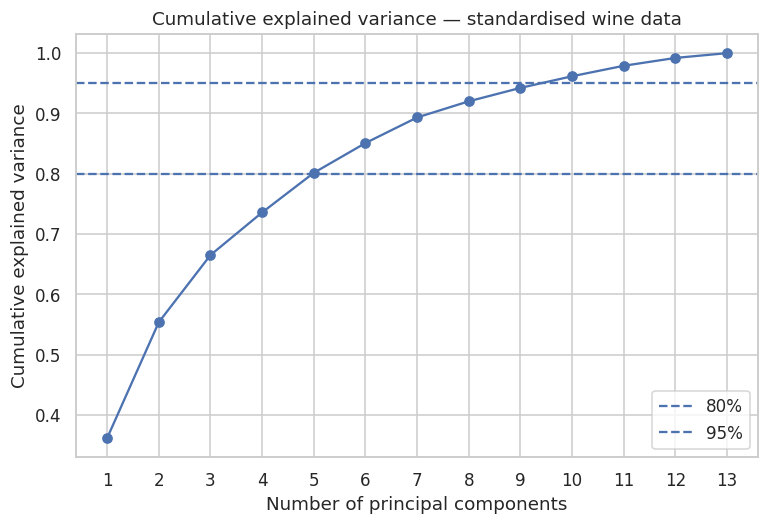

In [40]:
import matplotlib.pyplot as plt

cumulative = _scaled_result["cumulative"]

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(cumulative) + 1),
    cumulative,
    marker="o"
)

plt.axhline(0.80, linestyle="--", label="80%")
plt.axhline(0.95, linestyle="--", label="95%")

plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("Cumulative explained variance — standardised wine data")
plt.xticks(range(1, len(cumulative) + 1))
plt.grid(True)
plt.legend()
plt.show()

**Your answer:**

**(a)** The first principal component in the unstandardised wine data is essentially measuring **proline**. The reason is that proline has a much larger numerical scale than most of the other wine features, so it contributes much more to the total variance. PCA finds directions of maximum variance, so the large scale of proline dominates the first principal component, which explains about **99.81%** of the variance.

This shows that PCA should generally not be applied directly to variables measured on very different scales. Standardising the features first prevents a variable from dominating PCA simply because its numerical values are larger.

**(b)** Instead of choosing 80% or 95% arbitrarily, the number of components should be selected according to the actual downstream task. One possible procedure is to treat the number of components as a hyperparameter. Different values of `k` from 1 to 13 can be tested, and the complete modelling pipeline can be evaluated using cross-validation with a metric appropriate for the actual task. The value of `k` can then be selected based on the validation performance, while keeping the final test set separate for an unbiased final evaluation.

**(c)** The statement "component 2 is the strongest predictor" does not mean that the second original wine measurement is the strongest predictor. Each principal component is a linear combination of the original 13 measurements. To interpret component 2, its loadings should be examined to determine which original measurements contribute most strongly to it.

Therefore, from the sentence alone, we cannot conclude that a particular original wine measurement is the strongest predictor. We can only say that the second principal component was the most important predictor in that particular model.


## 11. Task 10 — A two-dimensional projection of 784 dimensions

Applied, and the last mechanical task. This is the projection Lesson 3
clusters.

`mnist_sample.csv` is 1500 handwritten digits, each a 28 by 28 image
flattened into 784 pixel columns. Reducing with PCA before running t-SNE
is standard practice: it removes noise and makes t-SNE several times
faster.

*see Practice 2 §15.2, §15.5 and §15.6*

In [41]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def project_two_ways(X, perplexity, seed, n_pca=50):
    """Project a high-dimensional array to 2-D, twice, and compare.

    Steps, in this order:
      1. standardise X with StandardScaler
      2. PCA to `n_pca` components, random_state=seed  -> the t-SNE input
      3. t-SNE from that reduction to 2 components, with the given
         `perplexity`, random_state=seed and init='pca'

    Separately, take the first TWO components of a PCA on the standardised
    data, so the linear and nonlinear projections can be compared.
    """

    # 1. Standardise the data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # 2. Reduce to n_pca dimensions for t-SNE
    pca_reduced = PCA(
        n_components=n_pca,
        random_state=seed
    )
    reduced = pca_reduced.fit_transform(X_scaled)

    # 3. Apply t-SNE to the PCA-reduced data
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=seed,
        init="pca"
    )
    tsne_2d = tsne.fit_transform(reduced)

    # Separate PCA directly to 2 dimensions
    pca_2 = PCA(
        n_components=2,
        random_state=seed
    )
    pca_2d = pca_2.fit_transform(X_scaled)

    # Fraction of variance explained by the two PCA components
    explained_2d = float(
        np.sum(pca_2.explained_variance_ratio_)
    )

    return {
        "pca_2d": pca_2d,
        "tsne_2d": tsne_2d,
        "explained_2d": explained_2d,
        "reduced": reduced
    }

In [42]:
mnist = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/mnist_sample.csv"
)
digit_labels = mnist["label"].values
pixels = mnist.drop(columns="label").values

print("pixels", pixels.shape, " labels", digit_labels.shape)
print("one row reshaped back into an image:", pixels[0].reshape(28, 28).shape)

# A 300-row subset keeps the assert cell below to a few seconds.
_small = pixels[:300]
_projection = project_two_ways(_small, perplexity=30, seed=SEED)

pixels (1500, 784)  labels (1500,)
one row reshaped back into an image: (28, 28)


In [ ]:
# LOCAL ALTERNATIVE. Run EITHER this cell OR the one above, not both.
# Above reads over the network and is what Colab needs. This one reads
# the same files from your checkout, for the dev-env container. The
# data is identical; only the address differs.
mnist = pd.read_csv("../datasets/mnist_sample.csv")
digit_labels = mnist["label"].values
pixels = mnist.drop(columns="label").values

print("pixels", pixels.shape, " labels", digit_labels.shape)
print("one row reshaped back into an image:", pixels[0].reshape(28, 28).shape)

# A 300-row subset keeps the assert cell below to a few seconds.
_small = pixels[:300]
_projection = project_two_ways(_small, perplexity=30, seed=SEED)

In [43]:
assert set(_projection) == {"pca_2d", "tsne_2d", "explained_2d", "reduced"}
assert _projection["pca_2d"].shape == (300, 2), f"pca_2d shape {_projection['pca_2d'].shape}"
assert _projection["tsne_2d"].shape == (300, 2), f"tsne_2d shape {_projection['tsne_2d'].shape}"
assert _projection["reduced"].shape == (300, 50), f"reduced shape {_projection['reduced'].shape}"
assert 0.0 < _projection["explained_2d"] < 1.0

# Two linear components cannot carry much of 784 dimensions.
assert _projection["explained_2d"] < 0.30, \
    f"two components explaining {_projection['explained_2d']:.1%} of 784 dimensions looks wrong"

# Seeded, so the same call reproduces exactly...
_again = project_two_ways(_small, perplexity=30, seed=SEED)
assert np.allclose(_projection["tsne_2d"], _again["tsne_2d"]), \
    "same seed must give the same embedding; did you pass random_state?"

# ...and a different seed does not.
_other = project_two_ways(_small, perplexity=30, seed=SEED + 1)
assert not np.allclose(_projection["tsne_2d"], _other["tsne_2d"]), \
    "a different seed should give a different embedding"

# t-SNE is not PCA: the two projections must differ.
assert not np.allclose(_projection["pca_2d"], _projection["tsne_2d"])

# t-SNE places THESE points and has no rule for placing new ones. Ask the
# class, not an instance -- there is nothing to seed and nothing to fit.
assert not hasattr(TSNE, "transform"), \
    "t-SNE has no transform, which is why it cannot be a preprocessing step"
assert hasattr(PCA, "transform"), "PCA does have one, and that is the difference"

print(f"two PCA components carry {_projection['explained_2d']:.2%} of the variance")
print("Task 10 passed.")

two PCA components carry 13.58% of the variance
Task 10 passed.


### Question 7 — perplexity, and the seed

Using the **full** 1500 rows this time, produce three t-SNE projections at
`perplexity` = 5, 30 and 50, all with the same seed, and draw them side by
side coloured by `digit_labels`. Then produce two more at `perplexity=30`
with two **different** seeds.

**(a)** Describe how the picture changes across the three perplexities.
Roughly what is perplexity controlling — say it in terms of how many
neighbours each point is trying to stay close to. Which extreme shatters
the classes and which merges them?

**(b)** Your two different-seed runs at the same perplexity also differ.
Explain why t-SNE is seed-dependent at all, and what that means for a
figure published without a stated `random_state`.

**(c)** Compare any of your t-SNE panels with the `pca_2d` projection. The
t-SNE picture separates the digits far better. State **three things you
still cannot conclude** from it — refer to Practice 2 §15.7 — and say which
of the two projections you would use as input to a clustering algorithm,
and why.

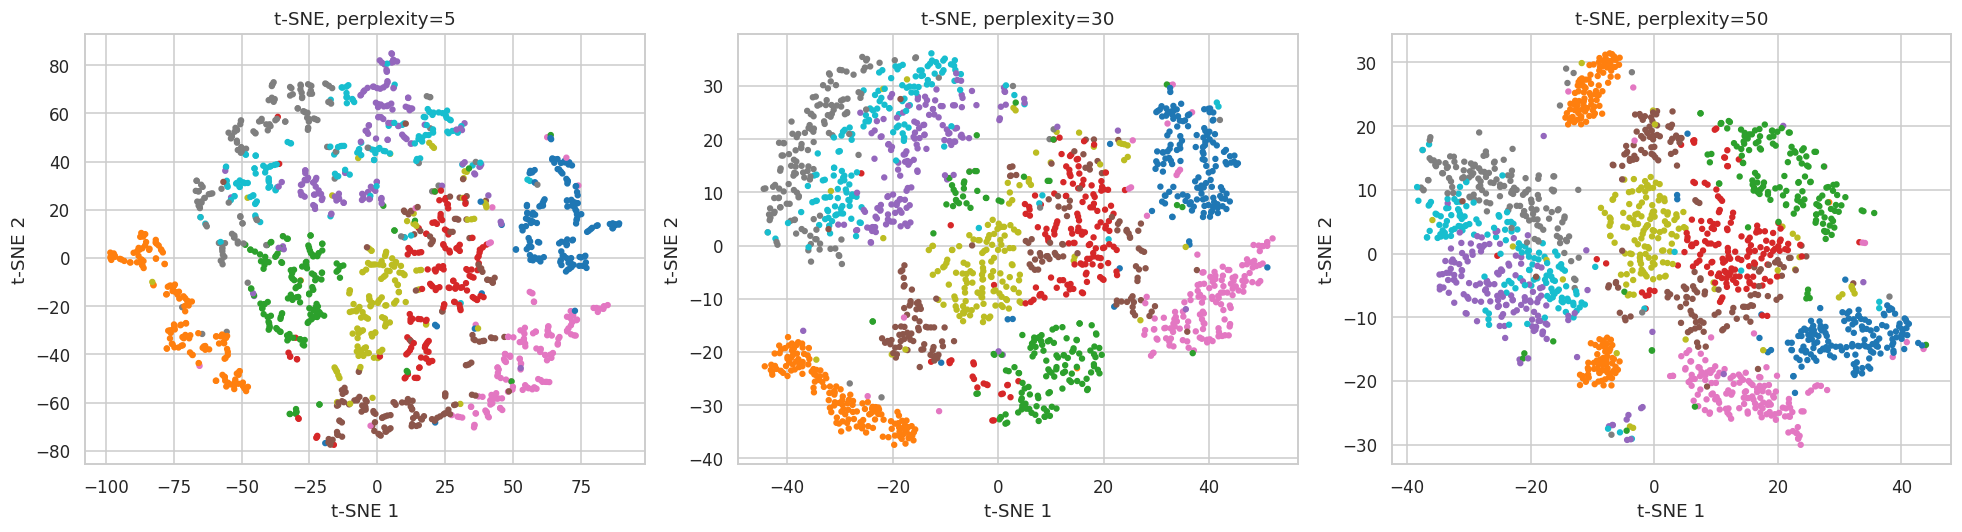

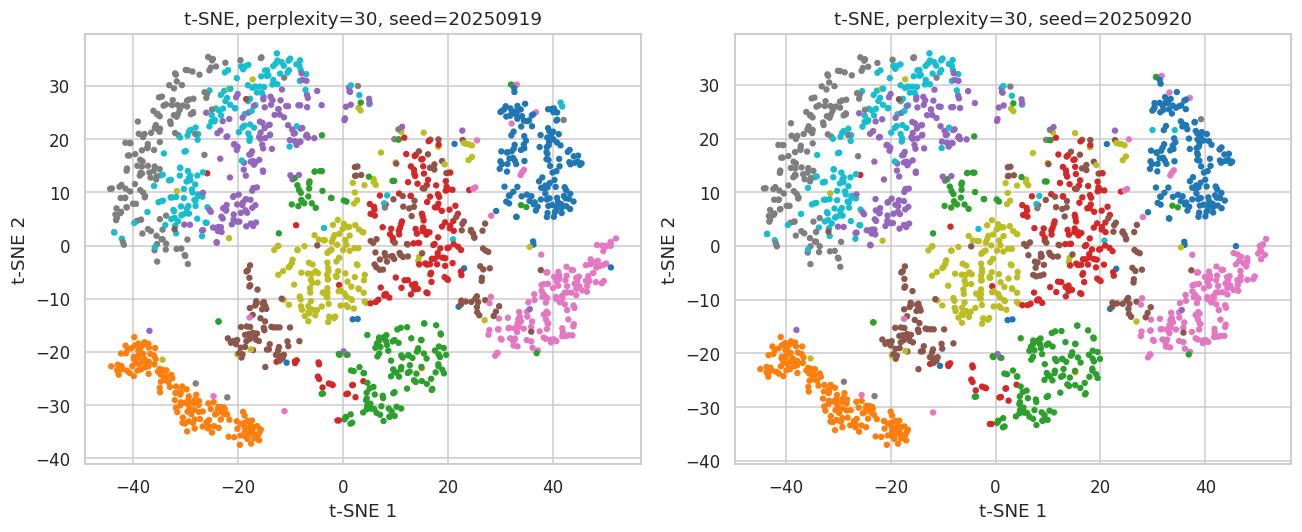

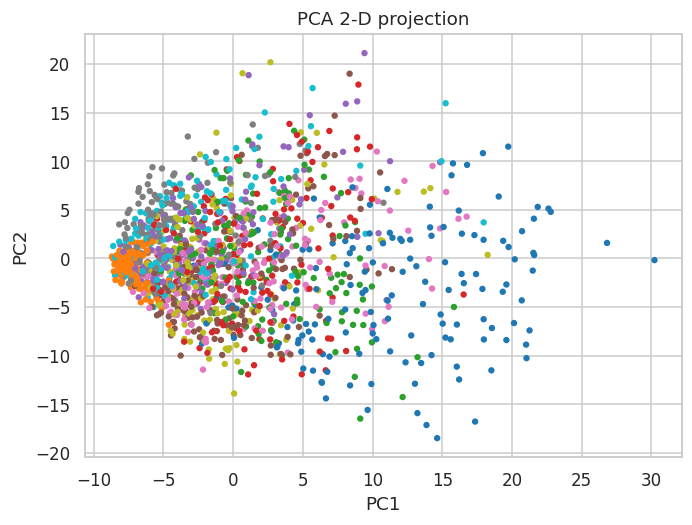

In [44]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Use all 1500 rows
X_full = pixels
y_full = digit_labels

# Standardise before PCA / t-SNE
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full)

# PCA to 50 dimensions before t-SNE
pca_50 = PCA(n_components=50, random_state=SEED)
X_reduced = pca_50.fit_transform(X_scaled)

# t-SNE with three different perplexities, same seed
tsne_5 = TSNE(
    n_components=2,
    perplexity=5,
    random_state=SEED,
    init="pca"
)
tsne_30 = TSNE(
    n_components=2,
    perplexity=30,
    random_state=SEED,
    init="pca"
)
tsne_50 = TSNE(
    n_components=2,
    perplexity=50,
    random_state=SEED,
    init="pca"
)

embedding_5 = tsne_5.fit_transform(X_reduced)
embedding_30 = tsne_30.fit_transform(X_reduced)
embedding_50 = tsne_50.fit_transform(X_reduced)

# Plot the three perplexities side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, embedding, perplexity in zip(
    axes,
    [embedding_5, embedding_30, embedding_50],
    [5, 30, 50]
):
    scatter = ax.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=y_full,
        cmap="tab10",
        s=10
    )
    ax.set_title(f"t-SNE, perplexity={perplexity}")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")

plt.tight_layout()
plt.show()


# Two runs with perplexity=30 and different seeds
tsne_seed_1 = TSNE(
    n_components=2,
    perplexity=30,
    random_state=SEED,
    init="pca"
)

tsne_seed_2 = TSNE(
    n_components=2,
    perplexity=30,
    random_state=SEED + 1,
    init="pca"
)

embedding_seed_1 = tsne_seed_1.fit_transform(X_reduced)
embedding_seed_2 = tsne_seed_2.fit_transform(X_reduced)

# Plot the two different seeds
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, embedding, seed in zip(
    axes,
    [embedding_seed_1, embedding_seed_2],
    [SEED, SEED + 1]
):
    ax.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=y_full,
        cmap="tab10",
        s=10
    )
    ax.set_title(f"t-SNE, perplexity=30, seed={seed}")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")

plt.tight_layout()
plt.show()


# PCA 2-D projection for comparison
pca_2d = PCA(n_components=2, random_state=SEED)
pca_projection = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(7, 5))
plt.scatter(
    pca_projection[:, 0],
    pca_projection[:, 1],
    c=y_full,
    cmap="tab10",
    s=10
)
plt.title("PCA 2-D projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

**Your answer:**

**(a)** Perplexity controls approximately how many neighbouring points each observation considers when constructing the local structure of the t-SNE embedding. A low perplexity, such as 5, focuses strongly on very local neighbourhoods, so the classes can become fragmented into many small groups. A higher perplexity, such as 50, considers a broader neighbourhood and tends to produce more merged and less locally fragmented structures. In this experiment, the lowest perplexity shatters the classes more strongly, while the highest perplexity tends to merge them more.

**(b)** t-SNE is seed-dependent because its optimisation starts from a random initial configuration and searches for a low-dimensional arrangement that preserves the desired neighbourhood structure. Different random seeds can therefore lead to different embeddings, even with the same data and perplexity. As a result, a published t-SNE figure should state the `random_state` (and other important settings such as perplexity), otherwise the exact result cannot be reproduced reliably.

**(c)** Although t-SNE can separate the digit classes much more clearly than the 2-D PCA projection, this does not mean that the distances between clusters have their original meaning. We also cannot conclude that the apparent cluster sizes or distances represent meaningful quantitative differences in the original 784-dimensional space. Finally, t-SNE is primarily a visualisation method and does not provide a general rule for placing new observations.

For clustering, I would use the PCA representation rather than the 2-D t-SNE representation. PCA provides a deterministic linear transformation that preserves global variance structure more directly and has a `transform` method for projecting new observations. t-SNE is mainly intended for visualisation and its 2-D coordinates can depend strongly on the chosen parameters and random seed.


## 12. Task 11 — A figure that answers a stated question

Applied. The question: **does the daily demand profile for bicycles differ
between working days and non-working days, and how does weather change
it?**

*see Practice 2 §8.4, §9 and §10*

In [45]:
import matplotlib.pyplot as plt

def demand_profile_figure(bikes_frame):
    """Draw a two-panel figure answering the question above. Return (fig, axes).

    Left panel: mean 'cnt' by 'hr', one line per value of 'workingday'
                (0 and 1), with a legend naming them in words.
    Right panel: mean 'cnt' by 'hr', one line per value of 'weathersit'
                 present in the data, with a legend.
    """

    # Create figure with two panels
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ----- Left panel: working days vs non-working days -----

    working_profile = (
        bikes_frame
        .groupby(["workingday", "hr"])["cnt"]
        .mean()
        .reset_index()
    )

    for workingday in sorted(working_profile["workingday"].unique()):
        data = working_profile[
            working_profile["workingday"] == workingday
        ]

        if workingday == 1:
            label = "Working day"
        else:
            label = "Non-working day"

        axes[0].plot(
            data["hr"],
            data["cnt"],
            label=label
        )

    axes[0].set_xlabel("Hour")
    axes[0].set_ylabel("Mean bicycle demand")
    axes[0].set_title("Demand by hour: working vs non-working days")
    axes[0].legend()


    # ----- Right panel: weather -----

    weather_profile = (
        bikes_frame
        .groupby(["weathersit", "hr"])["cnt"]
        .mean()
        .reset_index()
    )

    for weather in sorted(weather_profile["weathersit"].unique()):
        data = weather_profile[
            weather_profile["weathersit"] == weather
        ]

        axes[1].plot(
            data["hr"],
            data["cnt"],
            label=f"Weather {weather}"
        )

    axes[1].set_xlabel("Hour")
    axes[1].set_ylabel("Mean bicycle demand")
    axes[1].set_title("Demand by hour: weather conditions")
    axes[1].legend()


    # Overall figure title
    fig.suptitle(
        "Daily bicycle demand profile by working day and weather"
    )

    fig.tight_layout()

    return fig, axes

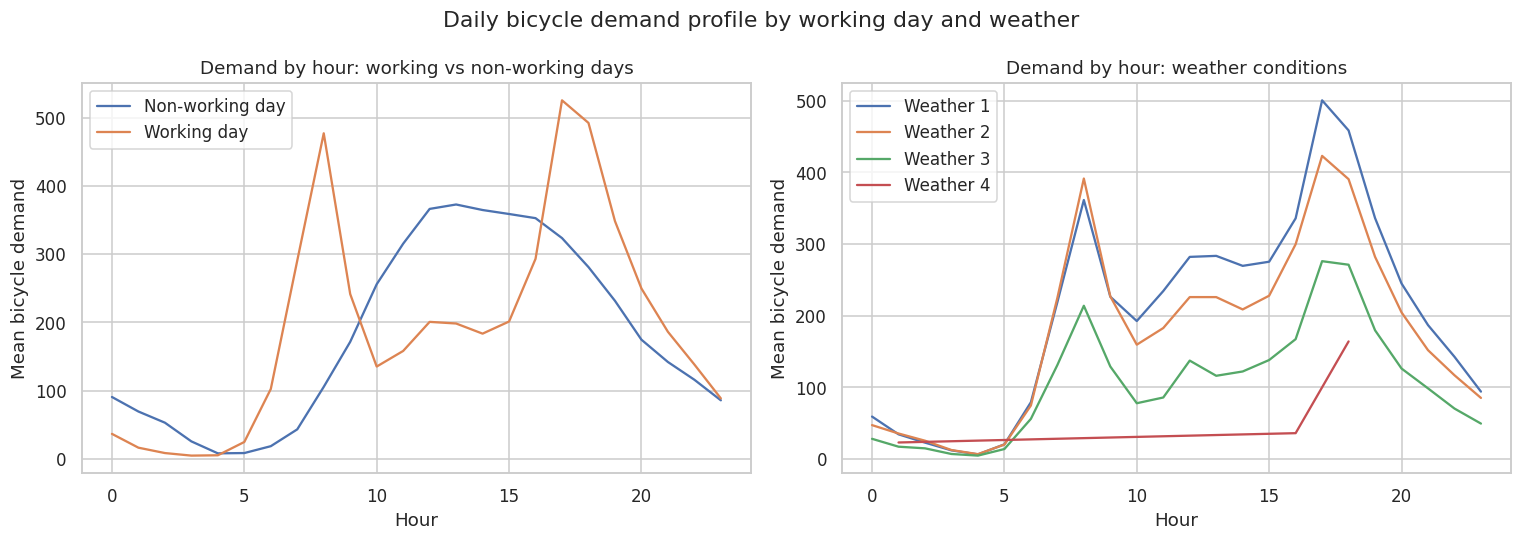

Task 11 passed.


In [46]:
_fig, _axes = demand_profile_figure(bikes)

assert len(_axes) == 2, f"expected two panels, got {len(_axes)}"
for _i, _ax in enumerate(_axes):
    assert _ax.get_xlabel(), f"panel {_i} has no x label"
    assert _ax.get_ylabel(), f"panel {_i} has no y label"
    assert _ax.get_title(), f"panel {_i} has no title"
    assert _ax.get_legend() is not None, f"panel {_i} has no legend"
    assert len(_ax.lines) >= 2, f"panel {_i} should have at least two lines"
assert _fig._suptitle is not None and _fig._suptitle.get_text(), "the figure has no suptitle"
assert len(_axes[0].lines) == 2, "the left panel compares exactly two groups"

plt.show()
print("Task 11 passed.")

### Question 8 — pooling and conditioning

**(a)** Draw the *pooled* profile as well: mean `cnt` by `hr` with no
conditioning. Compare it with your two-line left panel. Describe a
statement about commuter behaviour that the pooled figure would support
and that is false for both of the underlying groups.

**(b)** This is the same phenomenon as Practice 2 §12. Name it, and state
the general rule it implies about reporting an aggregate.

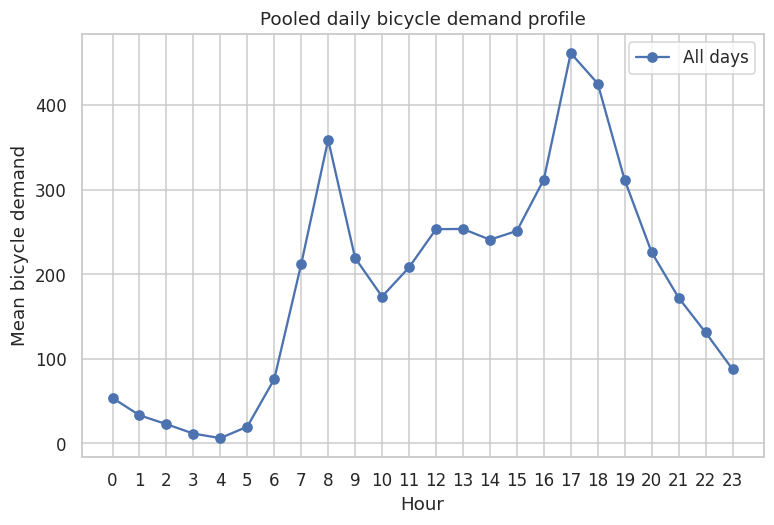

In [47]:
import matplotlib.pyplot as plt

# Pooled profile: mean cnt by hour, without conditioning
pooled_profile = bikes.groupby("hr")["cnt"].mean()

plt.figure(figsize=(8, 5))
plt.plot(
    pooled_profile.index,
    pooled_profile.values,
    marker="o",
    label="All days"
)

plt.xlabel("Hour")
plt.ylabel("Mean bicycle demand")
plt.title("Pooled daily bicycle demand profile")
plt.xticks(range(0, 24))
plt.grid(True)
plt.legend()
plt.show()

**Your answer:**

**(a)** The pooled profile averages bicycle demand across working and non-working days. It can therefore suggest a general commuter pattern that is not actually present within either group. For example, the pooled curve can make the morning and evening demand peaks appear as a general daily pattern for all days, even though the hourly profiles of working and non-working days differ substantially. Thus, a statement such as “commuter demand generally peaks in the morning and evening” is not valid for both underlying groups based only on the pooled figure.

**(b)** This is **Simpson's paradox**. The general rule is that an aggregate should not be reported without checking the relevant conditioning variables. When groups differ in composition or behaviour, pooling them can hide, weaken, or even reverse relationships that are present within the individual groups. Therefore, an aggregate should be interpreted together with the important subgroup structure.


## 13. Task 12 — Open-ended

No assert. Marked on the written analysis.

`bike_sharing_hourly.csv` is documented in `practice/datasets/README.md`.
Read that table first: four of the columns are integer-coded categories,
four are physical measurements that the publisher divided by a constant,
one is a date stored as text, and `casual + registered` equals `cnt`
exactly.

**Produce a short data-quality and structure report on this table.** Cover
at least:

1. **Types.** Which columns does pandas infer wrongly, in the sense that
   the inferred type permits an operation that is meaningless? Fix them
   and show one operation that becomes an error after your fix.
2. **Units.** Restore the four normalised columns to physical units and
   sanity-check the resulting ranges against what you know about
   Washington D.C. Report anything that looks wrong.
3. **The date.** Parse `dteday`. Confirm the series is complete: is there
   one row for every hour of every day in the range? If rows are missing,
   how many, and does their absence look random?
4. **A correlation you should not compute.** Produce the correlation
   matrix of the numeric columns, then identify at least two entries in it
   that are meaningless or misleading, and say why. At least one of your
   examples must be about an integer-coded category.
5. **Leakage.** Explain why `casual` and `registered` must not be used as
   features to predict `cnt`. Then describe a realistic prediction task
   for this dataset in which using them *would* be legitimate.
6. **A recommendation.** In one paragraph: which columns would you hand to
   a model that predicts hourly demand, and which would you exclude and
   why. Practice 3 §4 fits that model, so this is a real handover.

A good answer distinguishes "wrong" from "misleading" and says which of
its findings would actually change a modelling decision.

**Your write-up:**

_(replace this line)_

## 14. Before you submit

- Runtime → **Restart and run all**. Every cell executes in order, every
  assert passes.
- Every written question has an answer referring to numbers you produced.
- Task 12 has a written report, not only code.